# SimpleNN Distance Training

This notebook trains SimpleNN models on individual distances (d=3, 5, 7, 9, 11) using the best hyperparameters from tuning.

---

## 🔴 Key Difference from GraphSAGE

| Aspect | SimpleNN (this notebook) | GraphSAGE |
|--------|--------------------------|----------|
| **Input** | Flat syndrome array | Graph structure |
| **Extrapolation** | ❌ Cannot extrapolate (fixed input size) | ✅ Can extrapolate |
| **Strategy** | Train **separate model per distance** | Train one model on mixed distances |
| **Comparison** | Specialist approach | Generalist approach |

**Why this matters:** SimpleNN's input layer is fixed to the number of detectors for a specific distance.
A model trained on d=5 (60 detectors) cannot process d=7 (108 detectors) or d=9 (180 detectors).
Therefore, we train one model per distance and compare against GraphSAGE's single extrapolating model.

---

**Workflow:**
1. Load best hyperparameters from tuning results
2. For each distance d ∈ {3, 5, 7, 9, 11}:
   - Generate/load flat dataset (10⁶ samples)
   - Train SimpleNN model (50 epochs)
   - Save model and results
3. Models are saved for evaluation in testing.ipynb

## Imports

In [19]:
import sys
import json
import random
import time
import gc
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')  # code/nn/training -> code/

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Import from benchmark_models.py
from benchmark_models import (
    SurfaceCodeSampler,
    SimpleNNModel,
    SimpleNN,
    FlatDatasetCache,
)

# Set up paths
TRAINING_DIR = BASE_PATH / "nn" / "training"
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = TRAINING_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = TRAINING_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = TRAINING_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  TRAINING_DIR: {TRAINING_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  MODELS_DIR: {MODELS_DIR}")

Using device: cuda
GPU: NVIDIA GeForce GTX 1080

Paths:
  BASE_PATH: ..\..
  TRAINING_DIR: ..\..\nn\training
  RESULTS_DIR: ..\..\nn\training\results
  MODELS_DIR: ..\..\nn\training\models


## Configuration

In [20]:
# =============================================================================
# BEST HYPERPARAMETERS (loaded from tuning results)
# =============================================================================

# Load tuning results and find the best configuration
TUNING_RESULTS_PATH = BASE_PATH / "nn" / "tuning" / "results" / "results.json"

with open(TUNING_RESULTS_PATH, 'r') as f:
    tuning_results = json.load(f)

# Filter to completed results and find best by test accuracy
completed = [r for r in tuning_results if r.get('status') == 'completed']
best_result = max(completed, key=lambda x: x['test_accuracy'])
best_config = best_result['config']

# Extract hyperparameters
BEST_HYPERPARAMS = {
    'hidden_dims': tuple(best_config['hidden_dims']),
    'learning_rate': best_config['learning_rate'],
    'batch_size': best_config['batch_size'],
    'dropout': best_config['dropout'],
}

print(f"Loaded best hyperparameters from: {TUNING_RESULTS_PATH}")
print(f"Best config ID: {best_result['config_id']}")
print(f"Tuning performance: val_acc={best_result['val_accuracy']*100:.2f}%, test_acc={best_result['test_accuracy']*100:.2f}%")
print(f"\nHyperparameters:")
for k, v in BEST_HYPERPARAMS.items():
    print(f"  {k}: {v}")

Loaded best hyperparameters from: ..\..\nn\tuning\results\results.json
Best config ID: 33
Tuning performance: val_acc=87.69%, test_acc=87.76%

Hyperparameters:
  hidden_dims: (512, 1024, 2048)
  learning_rate: 0.0003
  batch_size: 64
  dropout: 0.1


In [ ]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

# Distances to train (one model per distance)
DISTANCES = [13]

# Total training samples per distance (10^6)
TOTAL_SAMPLES = 1_000_000

# Training parameters
EPOCHS = 10

# Error rate distribution for training data
P_VALUES = [0.001, 0.003, 0.005, 0.007]
P_WEIGHTS = [0.25, 0.25, 0.25, 0.25]

# Train/val/test split
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Random seed for reproducibility
SEED = 42

print(f"Training Configuration:")
print(f"  Distances: {DISTANCES}")
print(f"  Samples per distance: {TOTAL_SAMPLES:,}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BEST_HYPERPARAMS['batch_size']}")
print(f"  P values: {P_VALUES}")
print(f"  P weights: {P_WEIGHTS}")

Training Configuration:
  Distances: [3, 5, 7, 9, 11]
  Samples per distance: 1,000,000
  Epochs: 10
  Batch size: 64
  P values: [0.001, 0.003, 0.005, 0.007]
  P weights: [0.25, 0.25, 0.25, 0.25]


In [22]:
# =============================================================================
# SELECT WHICH DISTANCES TO TRAIN
# =============================================================================

# Set to None to train all distances, or specify a list
# Examples:
#   DISTANCES_TO_TRAIN = None  # Train all
#   DISTANCES_TO_TRAIN = [3]   # Train only d=3
#   DISTANCES_TO_TRAIN = [9, 11]  # Train only d=9 and d=11

DISTANCES_TO_TRAIN = None  # Train all distances

if DISTANCES_TO_TRAIN is None:
    distances_to_train = DISTANCES
else:
    distances_to_train = DISTANCES_TO_TRAIN

print(f"Distances to train: {distances_to_train}")

Distances to train: [3, 5, 7, 9, 11]


## Helper Functions

In [23]:
def get_num_detectors(d: int) -> int:
    """Calculate number of detectors for a given code distance."""
    # For rotated surface code: d rounds of (d^2 - 1) detectors
    # Actually for surface_code:rotated_memory_z with rounds=d
    # Generate a small sample to get the actual number
    import stim
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=d,
        distance=d,
        after_clifford_depolarization=0.001,
        after_reset_flip_probability=0.001,
        before_measure_flip_probability=0.001,
        before_round_data_depolarization=0.001
    )
    sampler = circuit.compile_detector_sampler()
    detection_events, _ = sampler.sample(1, separate_observables=True)
    return detection_events.shape[1]


def load_or_generate_dataset(d: int, n_samples: int):
    """Load from cache or generate flat dataset for a distance."""
    cache = FlatDatasetCache(base_path=BASE_PATH, device=device)
    cache_name = f"d{d}_training_1M"

    # Try to load from cache
    try:
        cache.load(cache_name, verbose=True)
        if len(cache) >= n_samples:
            print(f"Loaded {n_samples:,} samples from cache '{cache_name}'")
            detections, labels = cache.get_data()
            return detections[:n_samples], labels[:n_samples]
        else:
            print(f"Cache has {len(cache):,} samples, need {n_samples:,}. Regenerating...")
    except FileNotFoundError:
        print(f"No cache found for '{cache_name}'. Generating...")

    # Generate new dataset using cache.generate() (correct API)
    cache.generate(
        d=d,
        n_samples=n_samples,
        p_values=P_VALUES,
        p_weights=P_WEIGHTS,
        verbose=True
    )

    # Save to cache
    cache.save(cache_name)
    print(f"Generated and saved {n_samples:,} samples to '{cache_name}'")

    # Return the generated data
    detections, labels = cache.get_data()
    return detections, labels


def split_dataset(detections, labels, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Split dataset into train/val/test sets."""
    n = len(labels)

    # Shuffle with fixed seed
    torch.manual_seed(seed)
    perm = torch.randperm(n, device=detections.device)
    detections = detections[perm]
    labels = labels[perm]

    # Split
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_det, train_lab = detections[:train_end], labels[:train_end]
    val_det, val_lab = detections[train_end:val_end], labels[train_end:val_end]
    test_det, test_lab = detections[val_end:], labels[val_end:]

    print(f"Split: {len(train_lab):,} train, {len(val_lab):,} val, {len(test_lab):,} test")
    return (train_det, train_lab), (val_det, val_lab), (test_det, test_lab)


def evaluate_model(model, detections, labels, batch_size=256):
    """Evaluate model accuracy."""
    model.model.eval()
    correct = 0
    total = len(labels)

    with torch.no_grad():
        for i in range(0, total, batch_size):
            X = detections[i:i+batch_size]
            y = labels[i:i+batch_size]
            pred = model.model(X)
            correct += ((pred.squeeze() > 0.5).float() == y).sum().item()

    return correct / total if total > 0 else 0.0


def get_completed_distances():
    """Get set of already-completed distances from results file."""
    results_path = RESULTS_DIR / "results.json"
    if not results_path.exists():
        return set()
    with open(results_path, 'r') as f:
        results = json.load(f)
    return {r['distance'] for r in results if r.get('status') == 'completed'}


def save_result(result):
    """Append a result to the results file."""
    results_path = RESULTS_DIR / "results.json"

    if results_path.exists():
        with open(results_path, 'r') as f:
            results = json.load(f)
    else:
        results = []

    results.append(result)

    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)

    return len(results)

## Training Loop

Train one SimpleNN model per distance. Each model has a fixed input size matching the number of detectors for that distance.

In [24]:
# =============================================================================
# MAIN TRAINING LOOP
# =============================================================================

# Check which distances are already completed
completed_distances = get_completed_distances()
remaining_distances = [d for d in distances_to_train if d not in completed_distances]

print(f"Already completed: {sorted(completed_distances)}")
print(f"Remaining: {remaining_distances}")

if len(remaining_distances) == 0:
    print("\nAll distances are already completed!")
else:
    print(f"\n{'='*60}")
    print(f"Starting training - {len(remaining_distances)} distances")
    print(f"{'='*60}")

    for i, d in enumerate(remaining_distances):
        print(f"\n{'='*60}")
        print(f"Distance d={d} ({i+1}/{len(remaining_distances)})")
        print(f"{'='*60}")

        start_time = time.time()

        try:
            # Load or generate dataset
            detections, labels = load_or_generate_dataset(d, TOTAL_SAMPLES)

            # Split dataset
            (train_det, train_lab), (val_det, val_lab), (test_det, test_lab) = split_dataset(
                detections, labels, TRAIN_RATIO, VAL_RATIO, SEED
            )

            # Get number of detectors for this distance
            num_detectors = train_det.shape[1]
            print(f"Number of detectors: {num_detectors}")

            # Initialize model with best hyperparameters
            model = SimpleNN(
                nickname=f"d{d}_specialist",
                in_channels=num_detectors,
                hidden_dims=BEST_HYPERPARAMS['hidden_dims'],
                dropout=BEST_HYPERPARAMS['dropout'],
                device=device,
                base_path=BASE_PATH,
                seed=SEED + d  # Different seed per distance for variety
            )

            print(f"\nTraining with:")
            print(f"  hidden_dims: {BEST_HYPERPARAMS['hidden_dims']}")
            print(f"  learning_rate: {BEST_HYPERPARAMS['learning_rate']}")
            print(f"  batch_size: {BEST_HYPERPARAMS['batch_size']}")
            print(f"  dropout: {BEST_HYPERPARAMS['dropout']}")

            # Train the model
            epoch_losses = model.train_from_data(
                detections=train_det,
                labels=train_lab,
                epochs=EPOCHS,
                batch_size=BEST_HYPERPARAMS['batch_size'],
                lr=BEST_HYPERPARAMS['learning_rate'],
                verbose=True
            )

            # Evaluate on validation and test sets
            val_accuracy = evaluate_model(model, val_det, val_lab)
            test_accuracy = evaluate_model(model, test_det, test_lab)

            training_time = time.time() - start_time

            # Save model checkpoint
            model_path = MODELS_DIR / f"d{d}_specialist.pt"
            torch.save({
                'state_dict': model.model.state_dict(),
                'distance': d,
                'num_detectors': num_detectors,
                'hyperparams': BEST_HYPERPARAMS,
                'val_accuracy': val_accuracy,
                'test_accuracy': test_accuracy,
            }, model_path)

            # Record result
            result = {
                'distance': d,
                'num_detectors': num_detectors,
                'hyperparams': {
                    'hidden_dims': list(BEST_HYPERPARAMS['hidden_dims']),
                    'learning_rate': BEST_HYPERPARAMS['learning_rate'],
                    'batch_size': BEST_HYPERPARAMS['batch_size'],
                    'dropout': BEST_HYPERPARAMS['dropout'],
                },
                'status': 'completed',
                'val_accuracy': val_accuracy,
                'test_accuracy': test_accuracy,
                'final_loss': epoch_losses[-1] if epoch_losses else None,
                'training_time_seconds': training_time,
                'total_samples': TOTAL_SAMPLES,
                'epochs': EPOCHS,
                'model_path': str(model_path),
                'timestamp': datetime.now().isoformat(),
            }

            n_saved = save_result(result)

            print(f"\nDistance d={d} COMPLETED")
            print(f"  Val accuracy: {val_accuracy:.4f}")
            print(f"  Test accuracy: {test_accuracy:.4f}")
            print(f"  Final loss: {epoch_losses[-1]:.4f}")
            print(f"  Training time: {training_time:.1f}s ({training_time/60:.1f} min)")
            print(f"  Model saved: {model_path}")

        except Exception as e:
            print(f"\nDistance d={d} FAILED: {e}")
            import traceback
            traceback.print_exc()
            result = {
                'distance': d,
                'status': 'failed',
                'error': str(e),
                'timestamp': datetime.now().isoformat(),
            }
            save_result(result)

        finally:
            # Clean up GPU memory
            if 'model' in dir():
                del model
            if 'detections' in dir():
                del detections, labels
            if 'train_det' in dir():
                del train_det, train_lab, val_det, val_lab, test_det, test_lab
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    print(f"\n{'='*60}")
    print("ALL TRAINING COMPLETE")
    print(f"{'='*60}")

Already completed: []
Remaining: [3, 5, 7, 9, 11]

Starting training - 5 distances

Distance d=3 (1/5)
Loading flat dataset 'd3_training_1M' (95.4 MB)...
  Loaded 1,000,000 samples
  Detections shape: torch.Size([1000000, 24])
  Distance: d=3
  Error rates: [0.001, 0.003, 0.005, 0.007]
Loaded 1,000,000 samples from cache 'd3_training_1M'
Split: 800,000 train, 100,000 val, 100,000 test
Number of detectors: 24
SimpleNN initialized: SimpleNN(nickname='d3_specialist', in_channels=24, hidden_dims=(512, 1024, 2048), dropout=0.1)

Training with:
  hidden_dims: (512, 1024, 2048)
  learning_rate: 0.0003
  batch_size: 64
  dropout: 0.1

Training: SimpleNN(nickname='d3_specialist', in_channels=24, hidden_dims=(512, 1024, 2048), dropout=0.1)
Epochs: 10 | Batch size: 64 | LR: 0.0003
Training samples: 800000


Epoch 10/10: 100%|██████████| 12500/12500 [01:00<00:00, 205.63it/s, loss=0.0119, acc=0.9868]



Training complete! Final loss: 0.0378

Distance d=3 COMPLETED
  Val accuracy: 0.9868
  Test accuracy: 0.9868
  Final loss: 0.0378
  Training time: 585.2s (9.8 min)
  Model saved: ..\..\nn\training\models\d3_specialist.pt

Distance d=5 (2/5)
Loading flat dataset 'd5_training_1M' (461.6 MB)...
  Loaded 1,000,000 samples
  Detections shape: torch.Size([1000000, 120])
  Distance: d=5
  Error rates: [0.001, 0.003, 0.005, 0.007]
Loaded 1,000,000 samples from cache 'd5_training_1M'
Split: 800,000 train, 100,000 val, 100,000 test
Number of detectors: 120
SimpleNN initialized: SimpleNN(nickname='d5_specialist', in_channels=120, hidden_dims=(512, 1024, 2048), dropout=0.1)

Training with:
  hidden_dims: (512, 1024, 2048)
  learning_rate: 0.0003
  batch_size: 64
  dropout: 0.1

Training: SimpleNN(nickname='d5_specialist', in_channels=120, hidden_dims=(512, 1024, 2048), dropout=0.1)
Epochs: 10 | Batch size: 64 | LR: 0.0003
Training samples: 800000


Epoch 10/10: 100%|██████████| 12500/12500 [00:56<00:00, 222.36it/s, loss=0.0635, acc=0.9744]



Training complete! Final loss: 0.0635

Distance d=5 COMPLETED
  Val accuracy: 0.9655
  Test accuracy: 0.9673
  Final loss: 0.0635
  Training time: 588.5s (9.8 min)
  Model saved: ..\..\nn\training\models\d5_specialist.pt

Distance d=7 (3/5)
No cache found for 'd7_training_1M'. Generating...

Generating flat dataset: d=7, n_samples=1,000,000
Error rates: [0.001, 0.003, 0.005, 0.007] (weights: [0.25, 0.25, 0.25, 0.25])
SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)

Sampling 1,000,000 detection events...
  Detectors per sample: 336

Generated 1,000,000 samples
  Detections shape: torch.Size([1000000, 336])
  Labels shape: torch.Size([1000000])
  Positive rate: 0.2770
Flat dataset saved: ..\..\datasets\flat\d7_training_1M.pt
  Metadata: ..\..\datasets\flat\d7_training_1M.json
  Samples: 1,000,000
  Size: 1285.6 MB
Generated and saved 1,000,000 samples to 'd7_training_1M'
Split: 800,000 train, 100,000 val, 100,000 te

...


Training complete! Final loss: 0.2426

Distance d=7 COMPLETED
  Val accuracy: 0.8734
  Test accuracy: 0.8724
  Final loss: 0.2426
  Training time: 593.7s (9.9 min)
  Model saved: ..\..\nn\training\models\d7_specialist.pt

Distance d=9 (4/5)
No cache found for 'd9_training_1M'. Generating...

Generating flat dataset: d=9, n_samples=1,000,000
Error rates: [0.001, 0.003, 0.005, 0.007] (weights: [0.25, 0.25, 0.25, 0.25])
SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)

Sampling 1,000,000 detection events...
  Detectors per sample: 720

Generated 1,000,000 samples
  Detections shape: torch.Size([1000000, 720])
  Labels shape: torch.Size([1000000])
  Positive rate: 0.3496
Flat dataset saved: ..\..\datasets\flat\d9_training_1M.pt
  Metadata: ..\..\datasets\flat\d9_training_1M.json
  Samples: 1,000,000
  Size: 2750.4 MB
Generated and saved 1,000,000 samples to 'd9_training_1M'
Split: 800,000 train, 100,000 val, 100,000 te

Epoch 10/10: 100%|██████████| 12500/12500 [01:00<00:00, 207.01it/s, loss=0.6435, acc=0.6608]



Training complete! Final loss: 0.6471

Distance d=9 COMPLETED
  Val accuracy: 0.6498
  Test accuracy: 0.6498
  Final loss: 0.6471
  Training time: 638.8s (10.6 min)
  Model saved: ..\..\nn\training\models\d9_specialist.pt

Distance d=11 (5/5)
No cache found for 'd11_training_1M'. Generating...

Generating flat dataset: d=11, n_samples=1,000,000
Error rates: [0.001, 0.003, 0.005, 0.007] (weights: [0.25, 0.25, 0.25, 0.25])
SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)

Sampling 1,000,000 detection events...
  Detectors per sample: 1320

Generated 1,000,000 samples
  Detections shape: torch.Size([1000000, 1320])
  Labels shape: torch.Size([1000000])
  Positive rate: 0.3976
Flat dataset saved: ..\..\datasets\flat\d11_training_1M.pt
  Metadata: ..\..\datasets\flat\d11_training_1M.json
  Samples: 1,000,000
  Size: 5039.2 MB
Generated and saved 1,000,000 samples to 'd11_training_1M'
Split: 800,000 train, 100,000 val, 1

Epoch 10/10: 100%|██████████| 12500/12500 [00:57<00:00, 216.38it/s, loss=64.0625, acc=0.4171]



Training complete! Final loss: 60.2056

Distance d=11 COMPLETED
  Val accuracy: 0.3963
  Test accuracy: 0.3962
  Final loss: 60.2056
  Training time: 734.7s (12.2 min)
  Model saved: ..\..\nn\training\models\d11_specialist.pt

ALL TRAINING COMPLETE


## Results Summary

In [25]:
# =============================================================================
# LOAD AND DISPLAY RESULTS
# =============================================================================

results_path = RESULTS_DIR / "results.json"

if results_path.exists():
    with open(results_path, 'r') as f:
        results = json.load(f)

    # Filter to completed results
    completed = [r for r in results if r.get('status') == 'completed']
    print(f"Completed: {len(completed)} / {len(results)}")

    if completed:
        # Create summary DataFrame
        df_data = []
        for r in completed:
            df_data.append({
                'Distance': r['distance'],
                'Detectors': r['num_detectors'],
                'Val Acc': f"{r['val_accuracy']*100:.2f}%",
                'Test Acc': f"{r['test_accuracy']*100:.2f}%",
                'Final Loss': f"{r.get('final_loss', 0):.4f}",
                'Time (min)': f"{r.get('training_time_seconds', 0)/60:.1f}",
            })

        df = pd.DataFrame(df_data)
        df = df.sort_values('Distance')

        print("\nSimpleNN Specialist Models - Training Results:")
        print(df.to_string(index=False))

        print("\n" + "="*60)
        print("HYPERPARAMETERS USED (from tuning):")
        print("="*60)
        hp = completed[0]['hyperparams']
        print(f"  hidden_dims: {hp['hidden_dims']}")
        print(f"  learning_rate: {hp['learning_rate']}")
        print(f"  batch_size: {hp['batch_size']}")
        print(f"  dropout: {hp['dropout']}")
else:
    print("No results file found. Run the training loop first.")

Completed: 5 / 5

SimpleNN Specialist Models - Training Results:
 Distance  Detectors Val Acc Test Acc Final Loss Time (min)
        3         24  98.68%   98.68%     0.0378        9.8
        5        120  96.55%   96.73%     0.0635        9.8
        7        336  87.34%   87.24%     0.2426        9.9
        9        720  64.98%   64.98%     0.6471       10.6
       11       1320  39.63%   39.62%    60.2056       12.2

HYPERPARAMETERS USED (from tuning):
  hidden_dims: [512, 1024, 2048]
  learning_rate: 0.0003
  batch_size: 64
  dropout: 0.1


Plot saved to: ..\..\nn\training\plots\training_results.png


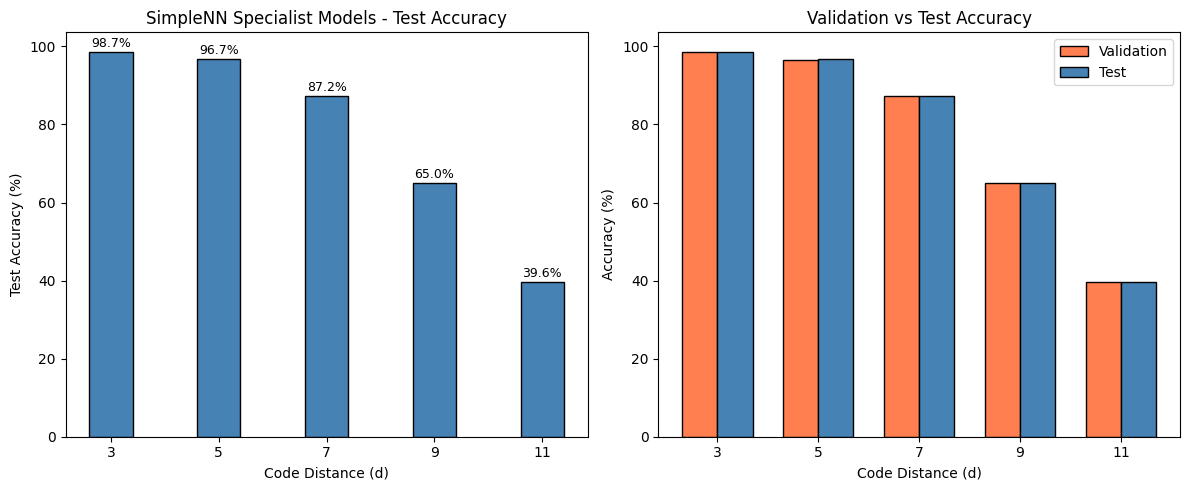

In [26]:
# =============================================================================
# PLOT RESULTS
# =============================================================================

if results_path.exists() and len(completed) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Sort by distance
    sorted_results = sorted(completed, key=lambda x: x['distance'])
    distances = [r['distance'] for r in sorted_results]
    test_accs = [r['test_accuracy'] * 100 for r in sorted_results]
    val_accs = [r['val_accuracy'] * 100 for r in sorted_results]

    # Plot 1: Test accuracy by distance
    ax1 = axes[0]
    ax1.bar(distances, test_accs, color='steelblue', edgecolor='black')
    ax1.set_xlabel('Code Distance (d)')
    ax1.set_ylabel('Test Accuracy (%)')
    ax1.set_title('SimpleNN Specialist Models - Test Accuracy')
    ax1.set_xticks(distances)
    for i, (d, acc) in enumerate(zip(distances, test_accs)):
        ax1.text(d, acc + 0.5, f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

    # Plot 2: Val vs Test accuracy
    ax2 = axes[1]
    x = np.arange(len(distances))
    width = 0.35
    ax2.bar(x - width/2, val_accs, width, label='Validation', color='coral', edgecolor='black')
    ax2.bar(x + width/2, test_accs, width, label='Test', color='steelblue', edgecolor='black')
    ax2.set_xlabel('Code Distance (d)')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Validation vs Test Accuracy')
    ax2.set_xticks(x)
    ax2.set_xticklabels(distances)
    ax2.legend()

    plt.tight_layout()

    # Save plot
    plot_path = PLOTS_DIR / "training_results.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Plot saved to: {plot_path}")

    plt.show()